# Polynomial Regression — Feature Exploration

This notebook exemplifies the features **created** by polynomial regression:
how raw inputs are transformed into higher-degree terms, how degree choice affects fit quality,
the bias-variance tradeoff, and multi-feature interaction terms.

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Generate Sample Data

We create a synthetic 1-D dataset from a noisy sinusoidal function to simulate non-linear, real-world data.

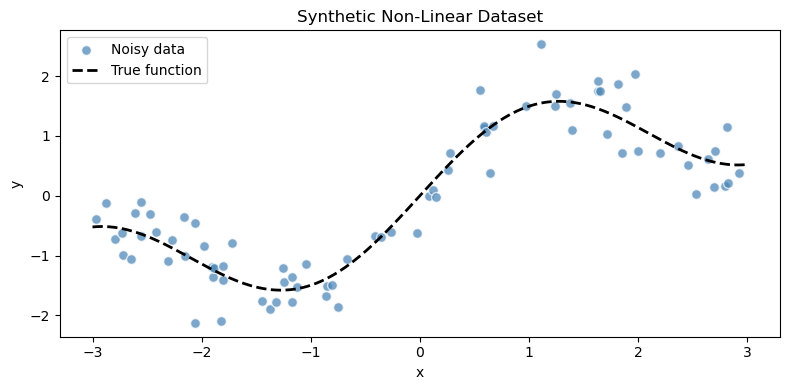

Dataset: 80 samples  |  x ∈ [-3, 3]


In [2]:
# True function: y = sin(1.5*x) + 0.5*x
n_samples = 80
X = np.sort(np.random.uniform(-3, 3, n_samples))
noise = np.random.normal(0, 0.4, n_samples)
y = np.sin(1.5 * X) + 0.5 * X + noise

# Reshape for sklearn
X_2d = X.reshape(-1, 1)

# Quick look at the data
plt.figure(figsize=(8, 4))
plt.scatter(X, y, color="steelblue", alpha=0.7, edgecolors="white", s=50, label="Noisy data")
x_line = np.linspace(-3, 3, 300)
plt.plot(x_line, np.sin(1.5 * x_line) + 0.5 * x_line, "k--", lw=2, label="True function")
plt.title("Synthetic Non-Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Dataset: {n_samples} samples  |  x ∈ [-3, 3]")

## 3. Fit Polynomial Regression Models

`PolynomialFeatures(degree=d)` expands a single feature $x$ into the vector:

$$[1,\ x,\ x^2,\ \dots,\ x^d]$$

We then fit a `LinearRegression` on the transformed features for degrees **1, 2, 3, 5, and 10**.

In [3]:
degrees = [1, 2, 3, 5, 10]
models = {}

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=True)
    X_poly = poly.fit_transform(X_2d)
    lr = LinearRegression()
    lr.fit(X_poly, y)
    models[d] = (poly, lr)
    print(f"Degree {d:2d}  →  {X_poly.shape[1]:2d} features: {poly.get_feature_names_out(['x']).tolist()}")

Degree  1  →   2 features: ['1', 'x']
Degree  2  →   3 features: ['1', 'x', 'x^2']
Degree  3  →   4 features: ['1', 'x', 'x^2', 'x^3']
Degree  5  →   6 features: ['1', 'x', 'x^2', 'x^3', 'x^4', 'x^5']
Degree 10  →  11 features: ['1', 'x', 'x^2', 'x^3', 'x^4', 'x^5', 'x^6', 'x^7', 'x^8', 'x^9', 'x^10']


## 4. Visualize Polynomial Fits

Each panel shows the same data with the fitted curve for a given degree.

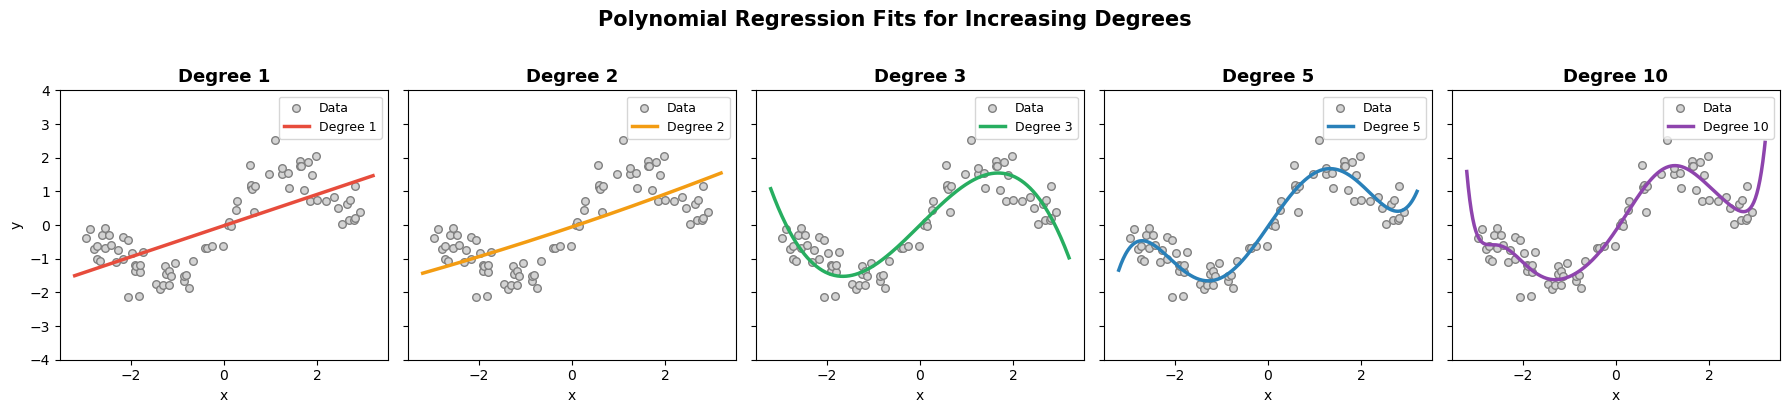

In [4]:
x_plot = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)
colors = ["#e74c3c", "#f39c12", "#27ae60", "#2980b9", "#8e44ad"]

fig, axes = plt.subplots(1, len(degrees), figsize=(18, 4), sharey=True)

for ax, d, color in zip(axes, degrees, colors):
    poly, lr = models[d]
    y_pred = lr.predict(poly.transform(x_plot))
    ax.scatter(X, y, color="lightgrey", edgecolors="grey", s=30, zorder=2, label="Data")
    ax.plot(x_plot, y_pred, color=color, lw=2.5, label=f"Degree {d}")
    ax.set_title(f"Degree {d}", fontsize=13, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylim(-4, 4)
    ax.legend(fontsize=9)

axes[0].set_ylabel("y")
fig.suptitle("Polynomial Regression Fits for Increasing Degrees", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Evaluate Model Performance

We use an 80/20 train-test split and report $R^2$, MSE, and RMSE for each polynomial degree.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

print(f"{'Degree':>7}  {'Train R²':>10}  {'Test R²':>9}  {'Train MSE':>10}  {'Test MSE':>9}  {'Test RMSE':>10}")
print("-" * 65)

metrics = {}
for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)

    train_r2  = r2_score(y_train, y_train_pred)
    test_r2   = r2_score(y_test,  y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse  = mean_squared_error(y_test,  y_test_pred)
    test_rmse = np.sqrt(test_mse)

    metrics[d] = dict(train_r2=train_r2, test_r2=test_r2,
                      train_mse=train_mse, test_mse=test_mse, test_rmse=test_rmse)
    print(f"{d:>7}  {train_r2:>10.4f}  {test_r2:>9.4f}  {train_mse:>10.4f}  {test_mse:>9.4f}  {test_rmse:>10.4f}")

 Degree    Train R²    Test R²   Train MSE   Test MSE   Test RMSE
-----------------------------------------------------------------
      1      0.4838     0.5535      0.7375     0.5199      0.7211
      2      0.4858     0.5197      0.7348     0.5593      0.7479
      3      0.8392     0.8351      0.2298     0.1920      0.4382
      5      0.8969     0.8823      0.1473     0.1370      0.3702
     10      0.8991     0.8835      0.1442     0.1357      0.3684


## 6. Bias-Variance Tradeoff

- **Low degree** → high bias (underfitting): the model is too simple to capture the true curve.  
- **High degree** → high variance (overfitting): the model memorises the training noise.

The sweet spot minimises **test error**.

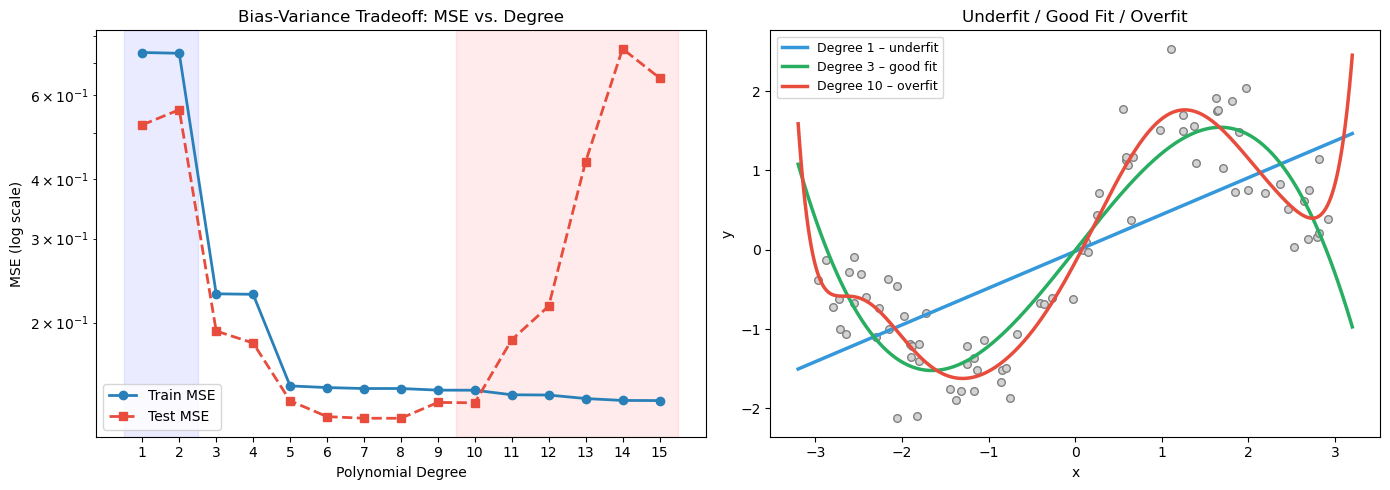

In [6]:
all_degrees = list(range(1, 16))
train_errors, test_errors = [], []

for d in all_degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    pipe.fit(X_train, y_train)
    train_errors.append(mean_squared_error(y_train, pipe.predict(X_train)))
    test_errors.append(mean_squared_error(y_test,  pipe.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MSE curves
ax = axes[0]
ax.plot(all_degrees, train_errors, "o-", color="#2980b9", label="Train MSE", lw=2)
ax.plot(all_degrees, test_errors,  "s--", color="#e74c3c", label="Test MSE",  lw=2)
ax.set_yscale("log")
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Bias-Variance Tradeoff: MSE vs. Degree")
ax.legend()
ax.set_xticks(all_degrees)
ax.axvspan(0.5, 2.5,  alpha=0.08, color="blue",  label="Underfitting region")
ax.axvspan(9.5, 15.5, alpha=0.08, color="red",   label="Overfitting region")

# Right: fits at degree 1 (underfit) vs 10 (overfit) vs 3 (good)
ax2 = axes[1]
ax2.scatter(X, y, color="lightgrey", edgecolors="grey", s=30, zorder=2)
highlight = {1: ("#3498db", "Degree 1 – underfit"),
             3: ("#27ae60", "Degree 3 – good fit"),
             10: ("#e74c3c", "Degree 10 – overfit")}
for d, (col, lbl) in highlight.items():
    poly, lr = models[d]
    ax2.plot(x_plot, lr.predict(poly.transform(x_plot)), color=col, lw=2.5, label=lbl)
ax2.set_title("Underfit / Good Fit / Overfit")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Feature Interaction Terms (2-D Input)

When the input has **two features** $(x_1, x_2)$, `PolynomialFeatures` generates all monomials up to degree $d$:

$$[1,\ x_1,\ x_2,\ x_1^2,\ x_1 x_2,\ x_2^2,\ \ldots]$$

Below we inspect the generated feature names and fit a degree-2 polynomial surface.

In [7]:
# --- 7a. Show generated feature names for degrees 1–4 ---
print("Generated polynomial feature names for 2-D input [x1, x2]:\n")
for d in range(1, 5):
    pf = PolynomialFeatures(degree=d, include_bias=True)
    pf.fit(np.zeros((1, 2)))
    names = pf.get_feature_names_out(["x1", "x2"])
    print(f"  Degree {d}  ({len(names)} features): {list(names)}")

Generated polynomial feature names for 2-D input [x1, x2]:

  Degree 1  (3 features): ['1', 'x1', 'x2']
  Degree 2  (6 features): ['1', 'x1', 'x2', 'x1^2', 'x1 x2', 'x2^2']
  Degree 3  (10 features): ['1', 'x1', 'x2', 'x1^2', 'x1 x2', 'x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3']
  Degree 4  (15 features): ['1', 'x1', 'x2', 'x1^2', 'x1 x2', 'x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3', 'x1^4', 'x1^3 x2', 'x1^2 x2^2', 'x1 x2^3', 'x2^4']


Degree-2 polynomial surface — learned coefficients:
             1: +0.0000
            x1: -0.0016
            x2: +0.8081
          x1^2: +0.4850
         x1 x2: -0.3054
          x2^2: -0.0099
     intercept: +0.0429


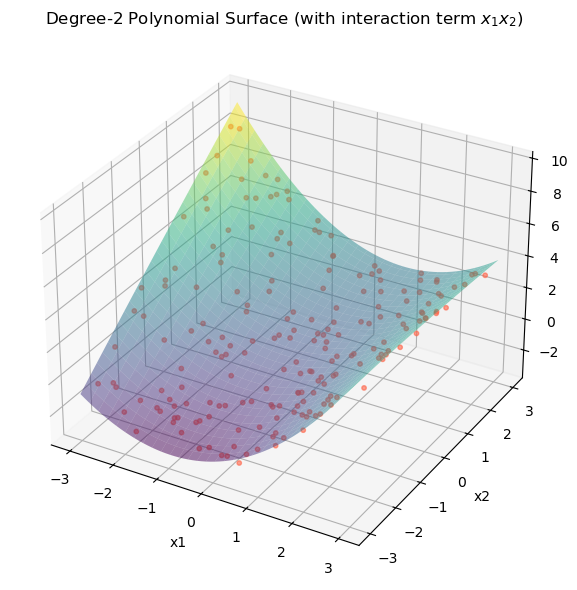

In [8]:
# --- 7b. Fit a degree-2 polynomial surface to 2-D data ---
# True surface: z = 0.5*x1^2 - 0.3*x1*x2 + 0.8*x2 + noise
rng = np.random.RandomState(0)
n2 = 200
X2 = rng.uniform(-3, 3, (n2, 2))
z  = 0.5*X2[:,0]**2 - 0.3*X2[:,0]*X2[:,1] + 0.8*X2[:,1] + rng.normal(0, 0.3, n2)

pf2 = PolynomialFeatures(degree=2, include_bias=True)
X2_poly = pf2.fit_transform(X2)
lr2 = LinearRegression().fit(X2_poly, z)

print("Degree-2 polynomial surface — learned coefficients:")
for name, coef in zip(pf2.get_feature_names_out(["x1","x2"]), lr2.coef_):
    print(f"  {name:>12s}: {coef:+.4f}")
print(f"  {'intercept':>12s}: {lr2.intercept_:+.4f}")

# Plot the fitted surface
x1_r = np.linspace(-3, 3, 60)
x2_r = np.linspace(-3, 3, 60)
X1g, X2g = np.meshgrid(x1_r, x2_r)
Xg_flat = np.column_stack([X1g.ravel(), X2g.ravel()])
Zg = lr2.predict(pf2.transform(Xg_flat)).reshape(X1g.shape)

fig = plt.figure(figsize=(10, 6))
ax3d = fig.add_subplot(111, projection="3d")
ax3d.plot_surface(X1g, X2g, Zg, alpha=0.5, cmap="viridis", edgecolor="none")
ax3d.scatter(X2[:,0], X2[:,1], z, color="tomato", s=10, alpha=0.6, label="Data")
ax3d.set_xlabel("x1"); ax3d.set_ylabel("x2"); ax3d.set_zlabel("z")
ax3d.set_title("Degree-2 Polynomial Surface (with interaction term $x_1 x_2$)")
plt.tight_layout()
plt.show()